# AI와빅데이터경영입문 기말과제

- 학번: 202457-352014
- 이름: 신승엽
- 학과: 첨단공학부 AI전공
- 연락처: 010-4195-1949

---

## 다이아몬드(diamonds) 가격 예측 모델 구축

seaborn 라이브러리의 다이아몬드(diamonds) 데이터를 활용하여 다이아몬드 가격(price)을 추정하는 예측 모델을 구축한다.
데이터 탐색과 시각화로 변수들의 관계를 살펴본 뒤, 선형회귀 / 의사결정나무 / 인공신경망 세 가지 모형을 만들어 성능을 비교하고,
하이퍼파라미터를 조정하면서 어떤 설정이 예측 성능에 영향을 주는지 확인하였다.

## (1) 데이터 로드하기

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 구글 코랩 / 로컬 한글 폰트 설정
import os
if 'COLAB_RELEASE_TAG' in os.environ:
    !apt-get install -y fonts-nanum > /dev/null 2>&1
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 다이아몬드 데이터 로드
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# 기본 통계량 확인
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [4]:
# 데이터 타입 및 결측치 확인
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


### 발견한 사실
- diamonds 데이터셋은 53,940개의 행과 10개의 열로 구성되어 있다.
- 수치형 변수 7개(carat, depth, table, price, x, y, z), 범주형 변수 3개(cut, color, clarity)로 나뉜다.
- 결측치는 하나도 없어서 별도의 결측치 처리 없이 바로 분석에 들어갈 수 있다.
- 목표 변수인 price는 최솟값 326달러, 최댓값 18,823달러로 범위가 넓고 오른쪽으로 꼬리가 긴 분포를 가진다.

## (2) 데이터 탐색 및 시각화

가격(price)과 다른 변수들의 관계를 상자그림, 바이올린그림, 상관계수 히트맵, 회귀선 그래프로 살펴본다.

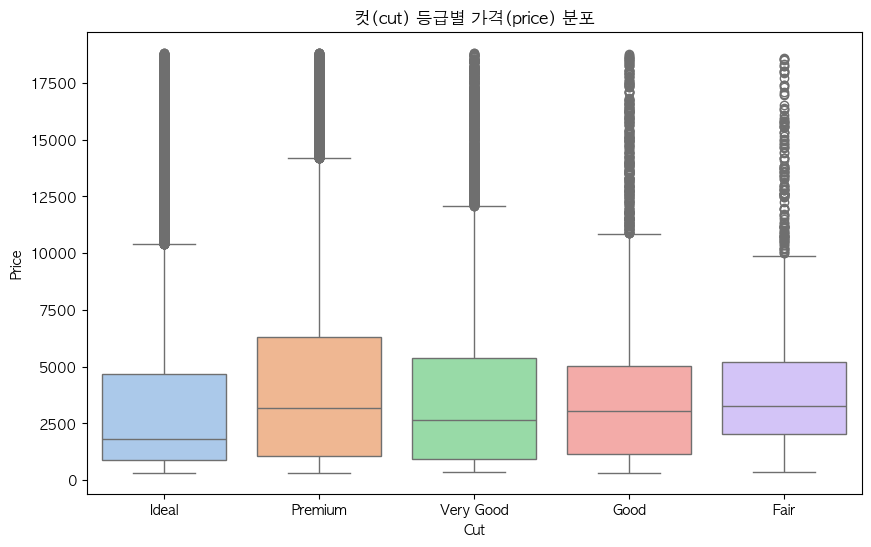

In [5]:
# 상자그림: 컷(cut) 등급별 가격(price) 분포
plt.figure(figsize=(10, 6))
sns.boxplot(x="cut", y="price", data=diamonds, palette="pastel")
plt.title('컷(cut) 등급별 가격(price) 분포')
plt.xlabel('Cut')
plt.ylabel('Price')
plt.show()

### 해석
- 직관적으로는 Ideal 등급이 가장 비쌀 것 같지만, 실제 중앙값은 등급 순서대로 깔끔하게 정렬되지 않는다. 오히려 Premium이나 Fair 쪽 중앙값이 더 높게 나타나기도 한다.
- 이는 가격이 컷 등급 하나로 결정되는 게 아니라 캐럿 같은 다른 변수와 얽혀 있기 때문으로 보인다. 큰 원석은 완벽한 비율로 깎기 어려워 낮은 컷 등급으로 분류되면서도 무게(캐럿) 때문에 가격은 높아지는 경향이 있다.
- 모든 등급에서 위쪽으로 이상치가 길게 뻗어 있다. 고가 다이아몬드가 폭넓게 존재한다는 의미다.

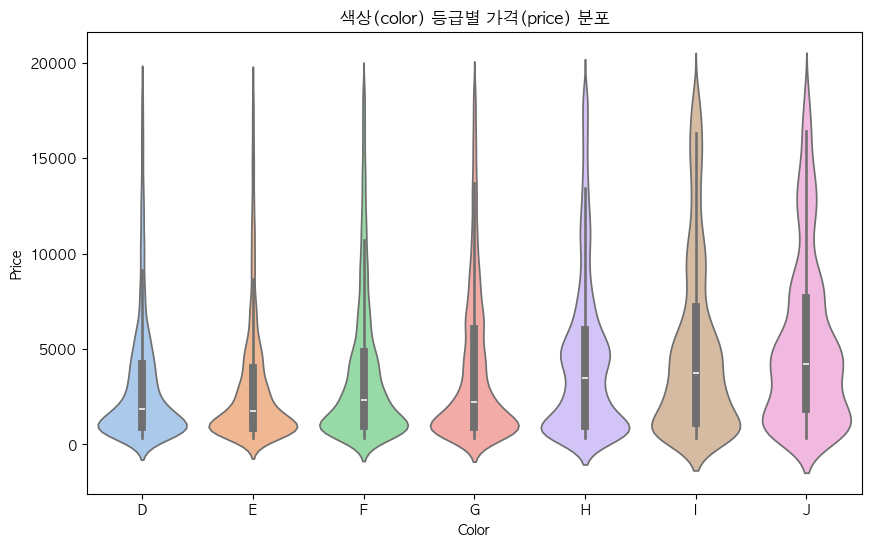

In [6]:
# 바이올린그림: 색상(color) 등급별 가격(price) 분포
plt.figure(figsize=(10, 6))
sns.violinplot(x="color", y="price", data=diamonds, palette="pastel")
plt.title('색상(color) 등급별 가격(price) 분포')
plt.xlabel('Color')
plt.ylabel('Price')
plt.show()

### 해석
- color는 D(가장 무색, 고급)부터 J(약간 노란빛)까지인데, 등급이 낮아질수록(D→J) 분포가 위쪽으로 넓어지면서 고가 구간의 밀도가 커진다.
- 색 등급이 좋은 D, E는 오히려 낮은 가격대에 두껍게 몰려 있다. 색이 좋은 다이아몬드는 작은 것이 많고, 색이 떨어지는 J 등급에는 큰(비싼) 다이아몬드가 섞여 있다는 뜻으로 보인다.
- 바이올린 모양이 전반적으로 아래쪽이 두꺼운 형태라, 저가 다이아몬드가 압도적으로 많다는 것을 알 수 있다.

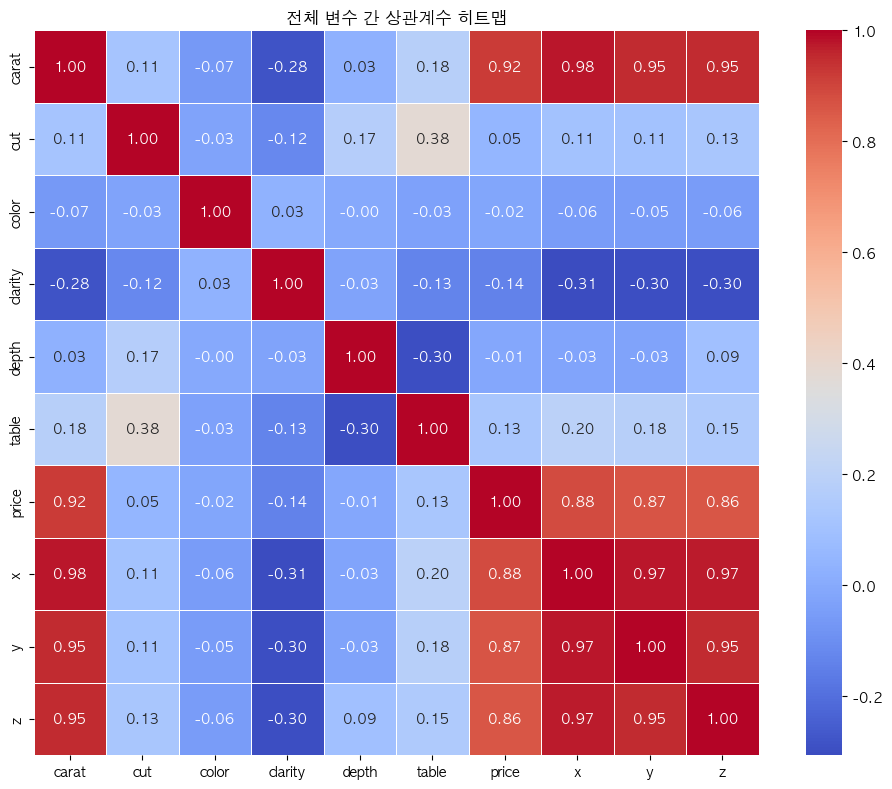

In [7]:
# 문자열(범주형) 변수를 숫자 인수(factor)로 변환한 모델링용 데이터프레임
df = diamonds.copy()
df['cut'] = pd.factorize(df['cut'])[0]
df['color'] = pd.factorize(df['color'])[0]
df['clarity'] = pd.factorize(df['clarity'])[0]

# 상관계수 행렬 계산 후 히트맵
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('전체 변수 간 상관계수 히트맵')
plt.tight_layout()
plt.show()

### 해석
- price와 가장 상관이 높은 변수는 carat(0.92)이다. 그 다음으로 물리적 크기인 x, y, z(0.86~0.89)가 높다. 결국 다이아몬드 가격은 무게와 크기가 핵심 요인이다.
- carat과 x, y, z는 서로 0.95 이상으로 거의 같이 움직인다. 크면 무겁고 길이도 길어지니 당연한데, 회귀분석에서는 이 변수들 사이의 다중공선성을 신경 써야 한다.
- cut, color, clarity를 숫자로 변환해 함께 보니 price와의 상관은 절댓값 기준으로 낮은 편이다(0.05~0.15). 단순 상관만 보면 약해 보이지만, factorize는 등급의 순서 정보를 그대로 살리지 못하기 때문에 실제 영향이 과소평가될 수 있다는 점도 감안해야 한다.
- depth, table은 다른 변수들과 상관이 거의 없다. 비율을 나타내는 값이라 절대 크기나 가격과는 직접 연결되지 않는 것으로 보인다.

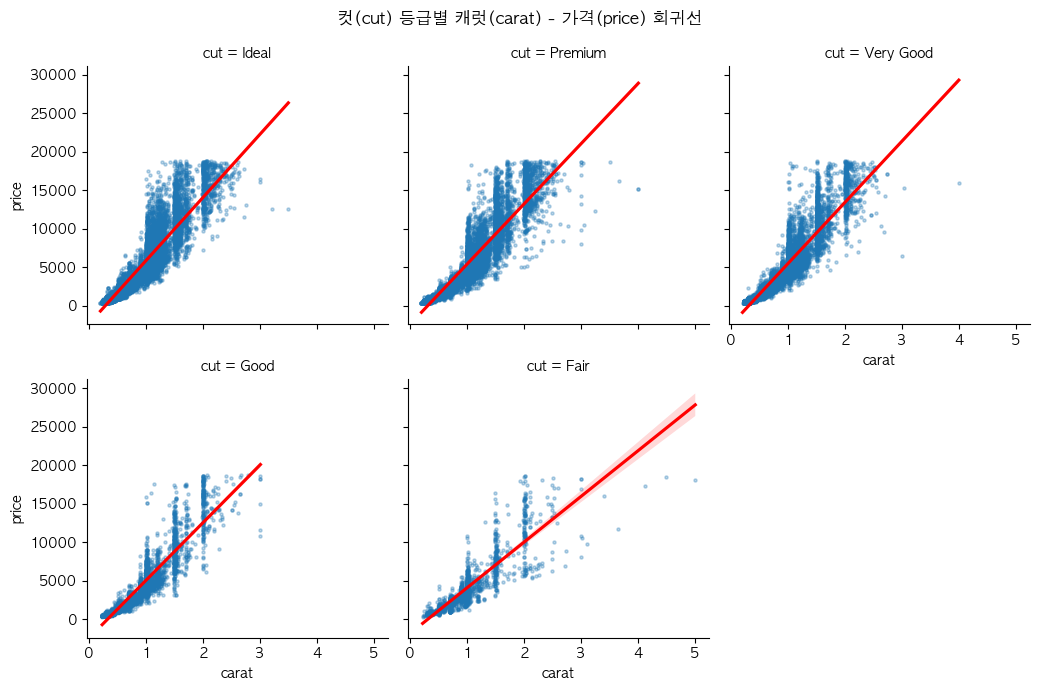

In [8]:
# 회귀선 그래프: 캐럿(carat)과 가격(price)의 관계를 컷(cut) 등급별로
sns.lmplot(x="carat", y="price", col="cut", data=diamonds,
           col_wrap=3, height=3.5, scatter_kws={'s': 5, 'alpha': 0.3}, line_kws={'color': 'red'})
plt.subplots_adjust(top=0.9)
plt.suptitle('컷(cut) 등급별 캐럿(carat) - 가격(price) 회귀선')
plt.show()

### 해석
- 모든 컷 등급에서 캐럿이 커질수록 가격이 오르는 뚜렷한 양의 관계가 보인다. 회귀선의 기울기가 가팔라서 캐럿이 가격을 강하게 끌어올린다는 것을 확인할 수 있다.
- 다만 점들이 직선 주변에 깔끔하게 모이지 않고 캐럿이 커질수록 위아래로 크게 퍼진다. 같은 캐럿이라도 다른 요인(색상, 투명도, 컷)에 따라 가격 차이가 크다는 뜻이라, 단순 직선(선형회귀)만으로는 설명에 한계가 있을 것으로 예상된다.
- 등급별로 기울기가 조금씩 다른데, Ideal 등급의 기울기가 상대적으로 가팔라서 같은 캐럿 증가에 가격이 더 민감하게 반응하는 편이다.

## (3) 예측 모형 3가지 구축 및 성능 비교

수업에서 학습한 내용 중 **선형회귀, 의사결정나무, 인공신경망** 세 가지 모형을 선택하여 다이아몬드 가격을 예측한다.
성능 지표로는 결정계수(R^2, 1에 가까울수록 좋음)와 RMSE(예측 오차, 작을수록 좋음), MAE를 함께 사용한다.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 입력 변수(X)와 목표 변수(y) 분리
X = df.drop(columns=['price'])
y = df['price']

# 훈련:테스트 = 8:2 로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 표준화 (신경망 등 거리 기반 학습에 필요)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('훈련 데이터:', X_train.shape, ' 테스트 데이터:', X_test.shape)

# 성능 평가 함수
def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'[{name}]  R2 = {r2:.4f},  RMSE = {rmse:,.1f},  MAE = {mae:,.1f}')
    return {'모형': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae}

results = []

훈련 데이터: (43152, 9)  테스트 데이터: (10788, 9)


### 모형 1) 선형회귀분석 (Linear Regression)

In [10]:
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
y_pred_lin = lin.predict(X_test_scaled)
results.append(evaluate('선형회귀', y_test, y_pred_lin))

[선형회귀]  R2 = 0.8723,  RMSE = 1,424.5,  MAE = 847.8


### 모형 2) 의사결정나무 (Decision Tree)

In [11]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)   # 트리는 스케일 영향을 받지 않으므로 원본 사용
y_pred_tree = tree.predict(X_test)
results.append(evaluate('의사결정나무', y_test, y_pred_tree))

[의사결정나무]  R2 = 0.9655,  RMSE = 740.7,  MAE = 357.5


### 모형 3) 인공신경망 (Multi-Layer Perceptron)

In [12]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                   max_iter=300, random_state=42, early_stopping=True)
mlp.fit(X_train_scaled, y_train)   # 신경망은 반드시 표준화된 데이터 사용
y_pred_mlp = mlp.predict(X_test_scaled)
results.append(evaluate('인공신경망', y_test, y_pred_mlp))

[인공신경망]  R2 = 0.9540,  RMSE = 854.9,  MAE = 441.5


In [13]:
# 세 모형 성능 비교 표
result_df = pd.DataFrame(results).set_index('모형')
result_df

,R2,RMSE,MAE
모형,,,
선형회귀,0.872346,1424.534689,847.786339
의사결정나무,0.965486,740.719923,357.540184
인공신경망,0.954028,854.871992,441.469226


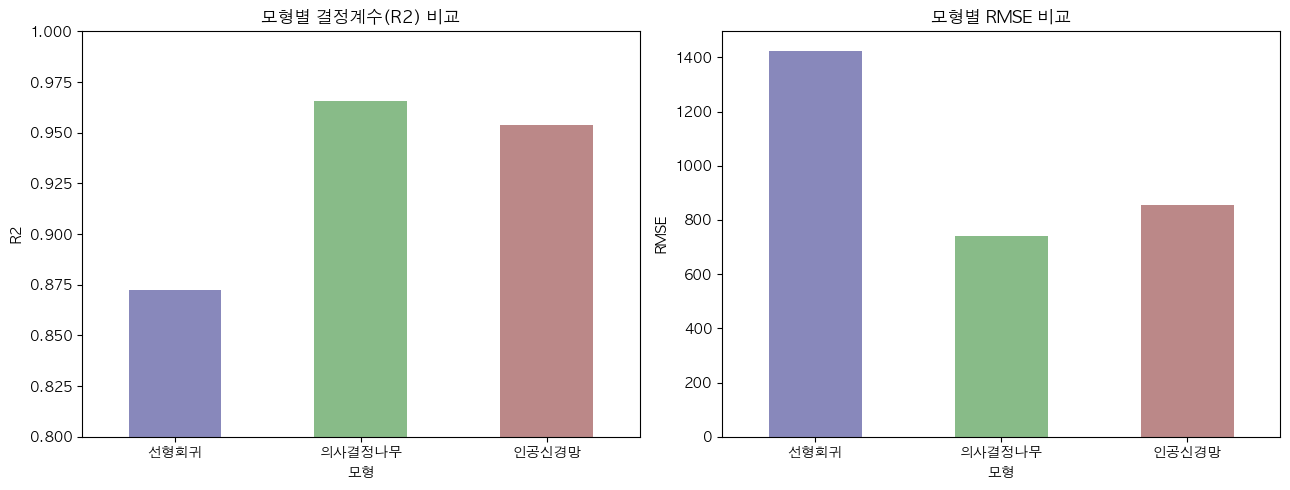

In [14]:
# 세 모형 성능 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
result_df['R2'].plot(kind='bar', ax=axes[0], color=['#88b', '#8b8', '#b88'])
axes[0].set_title('모형별 결정계수(R2) 비교'); axes[0].set_ylabel('R2'); axes[0].set_ylim(0.8, 1.0)
axes[0].tick_params(axis='x', rotation=0)
result_df['RMSE'].plot(kind='bar', ax=axes[1], color=['#88b', '#8b8', '#b88'])
axes[1].set_title('모형별 RMSE 비교'); axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 해석
- 세 모형 모두 R^2 0.87 이상으로 다이아몬드 가격을 잘 설명한다. 그중 **의사결정나무(R^2 약 0.97)가 가장 우수**했고, 인공신경망(약 0.95), 선형회귀(약 0.87) 순이었다.
- 선형회귀가 가장 낮았던 이유는 앞의 lmplot에서 봤듯이 캐럿-가격 관계가 직선이 아니라 캐럿이 커질수록 분산이 커지는 비선형 구조이기 때문이다. 직선 하나로는 이 곡선과 이분산성을 담아내기 어렵다.
- 의사결정나무는 구간을 나눠 비선형 관계를 유연하게 잡아내기 때문에 오차(RMSE)가 선형회귀의 절반 수준으로 줄었다.
- 인공신경망도 비선형을 학습하지만, 기본 설정만으로는 트리만큼의 성능에 도달하지 못했다. 하이퍼파라미터 조정의 여지가 크다는 의미이기도 하다.

## (4) 하이퍼파라미터 최적화

각 모형의 성능에 영향을 주는 요소들을 바꿔 가면서 비교한다.
(1) 훈련:테스트 분할 비율, (2) 데이터 표준화 방법, (3) 신경망 활성화 함수, (4) 의사결정나무 깊이와 앙상블(랜덤포레스트) 확장을 차례로 살펴본다.

### (4-1) 훈련 : 테스트 데이터 분할 비율 비교

In [15]:
# 인공신경망 기준으로 분할 비율을 6:4, 7:3, 8:2 로 바꿔 비교
split_rows = []
for ts in [0.4, 0.3, 0.2]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=ts, random_state=42)
    sc = StandardScaler().fit(Xtr)
    m = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42, early_stopping=True)
    m.fit(sc.transform(Xtr), ytr)
    pred = m.predict(sc.transform(Xte))
    split_rows.append({'분할(훈련:테스트)': f'{int((1-ts)*100)}:{int(ts*100)}',
                       'R2': r2_score(yte, pred), 'RMSE': np.sqrt(mean_squared_error(yte, pred))})
pd.DataFrame(split_rows).set_index('분할(훈련:테스트)')

,R2,RMSE
분할(훈련:테스트),,
60:40,0.943408,946.661431
70:30,0.952040,864.856921
80:20,0.954028,854.871992


### 해석
- 훈련 데이터 비율을 60%에서 80%로 늘릴수록 R^2가 조금씩 올라갔다(약 0.943 → 0.954). 학습에 쓰는 데이터가 많아질수록 모델이 패턴을 더 잘 배운다.
- 다만 차이가 크지 않은 것은 원본 데이터가 5만 건 이상으로 충분히 많아서, 60%만 써도 학습에 큰 부족함이 없기 때문이다. 이후 분석은 가장 성능이 좋았던 8:2 비율로 진행한다.

### (4-2) 데이터 표준화 방법 비교

In [16]:
from sklearn.preprocessing import MinMaxScaler

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
scale_rows = []
for name, scaler_obj in [('표준화 안 함', None), ('StandardScaler', StandardScaler()), ('MinMaxScaler', MinMaxScaler())]:
    if scaler_obj is None:
        a, b = Xtr, Xte
    else:
        scaler_obj.fit(Xtr); a, b = scaler_obj.transform(Xtr), scaler_obj.transform(Xte)
    m = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42, early_stopping=True)
    m.fit(a, ytr); pred = m.predict(b)
    scale_rows.append({'표준화 방법': name, 'R2': r2_score(yte, pred), 'RMSE': np.sqrt(mean_squared_error(yte, pred))})
pd.DataFrame(scale_rows).set_index('표준화 방법')

,R2,RMSE
표준화 방법,,
표준화 안 함,0.950124,890.433616
StandardScaler,0.954028,854.871992
MinMaxScaler,0.930179,1053.534000


### 해석
- 표준화 방법에 따라 신경망 성능이 달라졌다. **StandardScaler(평균 0, 표준편차 1)** 가 가장 좋았고(R^2 약 0.954), 표준화를 안 한 경우가 그 다음, MinMaxScaler(0~1 정규화)가 가장 낮았다.
- 신경망은 입력 변수들의 크기(scale)가 비슷해야 가중치 학습이 안정적이다. carat은 0부터 5, x/y/z는 0부터 10대인데 가격은 수천 단위라 스케일 차이가 커서, 표준화를 하면 학습이 한결 안정된다.
- MinMax가 오히려 나빴던 것은 이 데이터에 이상치(매우 큰 다이아몬드)가 많아, 최댓값 기준으로 0~1로 누르면 대부분의 값이 좁은 구간에 몰려 변별력이 떨어지기 때문으로 보인다. 이상치가 있는 데이터에서는 StandardScaler가 더 안전하다는 것을 확인했다.

### (4-3) 인공신경망 활성화 함수 비교

In [17]:
sc = StandardScaler().fit(Xtr)
a, b = sc.transform(Xtr), sc.transform(Xte)
act_rows = []
for act in ['relu', 'tanh', 'logistic']:
    m = MLPRegressor(hidden_layer_sizes=(64, 32), activation=act, max_iter=300, random_state=42, early_stopping=True)
    m.fit(a, ytr); pred = m.predict(b)
    act_rows.append({'활성화 함수': act, 'R2': r2_score(yte, pred), 'RMSE': np.sqrt(mean_squared_error(yte, pred))})
pd.DataFrame(act_rows).set_index('활성화 함수')

,R2,RMSE
활성화 함수,,
relu,0.954028,854.871992
tanh,-0.219773,4403.465457
logistic,-0.225907,4414.523609


### 해석
- 활성화 함수에 따라 성능 차이가 극단적으로 갈렸다. **relu만 R^2 약 0.95로 정상 학습**되었고, tanh와 logistic은 R^2가 음수로 나와 사실상 학습에 실패했다.
- tanh와 logistic은 출력이 각각 (-1, 1), (0, 1)로 포화(saturation)되는 함수다. 가격처럼 수천 단위의 큰 값을 예측해야 하는 회귀 문제에서 깊은 층을 거치면 기울기가 작아져(기울기 소실) 학습이 제대로 진행되지 않은 것으로 보인다.
- relu는 양수 구간에서 기울기가 1로 유지돼 기울기 소실이 덜하고 큰 값도 잘 전달한다. 회귀 문제에서 은닉층 활성화 함수로 relu가 사실상 표준처럼 쓰이는 이유를 직접 확인할 수 있었다.

### (4-4) 의사결정나무 깊이 조정과 앙상블(랜덤포레스트) 확장

In [18]:
from sklearn.ensemble import RandomForestRegressor

depth_rows = []
for d in [3, 5, 8, 12, None]:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(Xtr, ytr); pred = m.predict(Xte)
    depth_rows.append({'max_depth': str(d), 'R2': r2_score(yte, pred), 'RMSE': np.sqrt(mean_squared_error(yte, pred))})
depth_table = pd.DataFrame(depth_rows).set_index('max_depth')

# 트리를 여러 개 묶은 앙상블(랜덤포레스트)과 비교
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr); pred_rf = rf.predict(Xte)
print(f'[랜덤포레스트]  R2 = {r2_score(yte, pred_rf):.4f},  RMSE = {np.sqrt(mean_squared_error(yte, pred_rf)):,.1f}')
depth_table

[랜덤포레스트]  R2 = 0.9803,  RMSE = 558.9


,R2,RMSE
max_depth,,
3,0.882153,1368.720639
5,0.920591,1123.542562
8,0.961963,777.606004
12,0.972346,663.036820
None,0.965486,740.719923


### 해석
- 트리 깊이(max_depth)를 키우면 R^2가 올라가다가 **depth=12 부근에서 약 0.972로 가장 좋았고**, 깊이 제한을 풀면(None) 오히려 소폭 떨어졌다. 너무 깊은 트리는 훈련 데이터에 과적합되어 테스트 성능이 나빠지는 전형적인 모습이다.
- 적당한 깊이로 가지치기(pruning)를 해 주는 것이 일반화 성능에 도움이 된다는 것을 확인했다.
- 트리를 100개 묶은 **랜덤포레스트는 R^2 약 0.98로 단일 트리보다 더 높았다**. 여러 트리의 예측을 평균 내면 단일 트리의 과적합과 분산이 줄어들기 때문이다. 트리 계열 모형이 이 데이터에 특히 잘 맞는다는 것을 보여준다.

---

## 수행 과정에서 발견한 사실

1. **가격은 결국 크기(무게)다.** carat이 price와 상관계수 0.92로 압도적으로 높았고, 물리적 크기 x, y, z도 그 뒤를 이었다. 다이아몬드 가격을 예측할 때 무게/크기 변수가 가장 중요한 입력이라는 것을 모든 단계에서 일관되게 확인했다.

2. **컷, 색상 등급과 가격의 관계는 직관과 다르다.** 좋은 등급일수록 비쌀 것 같지만, 실제로는 등급이 낮은 쪽에 큰(비싼) 다이아몬드가 섞여 있어 boxplot/violinplot의 중앙값이 깔끔하게 정렬되지 않았다. 가격은 여러 변수가 얽혀 결정된다.

3. **비선형 모형이 선형회귀를 크게 앞섰다.** 캐럿-가격 관계가 곡선이고 분산이 커서, 직선을 가정하는 선형회귀(R^2 0.87)보다 의사결정나무(0.97)와 신경망(0.95)이 훨씬 정확했다.

4. **전처리와 하이퍼파라미터가 신경망 성능을 좌우했다.** 같은 신경망이라도 표준화 방법(Standard > 없음 > MinMax)과 활성화 함수(relu만 정상 학습, tanh/logistic은 실패)에 따라 성능이 크게 갈렸다. 모델 종류만큼이나 설정이 중요하다는 것을 체감했다.

5. **트리는 깊이 조절이 핵심이고, 앙상블이 더 강하다.** 트리는 너무 깊으면 과적합되어 적당한 깊이(약 12)에서 가장 좋았고, 트리를 여러 개 묶은 랜덤포레스트(0.98)가 단일 모형 중 가장 우수했다.

## 분석 결과에 대한 해석

이번 과제의 목표는 다이아몬드 가격을 예측하는 모델을 만드는 것이었다. 데이터 탐색 단계에서 가격을 가장 강하게 설명하는 변수는 캐럿(무게)이라는 점을 확인했고, 이는 상관계수 히트맵(carat-price 0.92)과 lmplot의 가파른 회귀선에서 분명하게 드러났다. 다만 캐럿이 커질수록 가격이 위아래로 크게 퍼지는 비선형/이분산 구조가 있어서, 단순한 직선 모형으로는 한계가 있을 것이라는 예상을 할 수 있었다.

실제로 세 모형을 비교했을 때 이 예상이 맞아떨어졌다. 선형회귀는 R^2 0.87로 가장 낮았고, 비선형을 유연하게 잡아내는 의사결정나무(0.97)와 인공신경망(0.95)이 더 우수했다. 오차(RMSE) 기준으로 보면 선형회귀는 평균 1,400달러가량 틀렸지만 트리 계열은 700~800달러 수준으로 절반가량 줄었다. 가격을 곡선으로 설명할 수 있는 모형이 이 데이터에 적합하다는 결론이다.

하이퍼파라미터 최적화에서는 모델을 고르는 것만큼 설정이 중요하다는 것을 배웠다. 특히 인공신경망은 표준화 방법과 활성화 함수에 따라 성능이 크게 흔들렸다. 이상치가 많은 이 데이터에서는 MinMax보다 StandardScaler가 안정적이었고, 활성화 함수는 relu만 정상적으로 학습되었으며 tanh/logistic은 기울기 소실로 학습에 실패했다. 트리는 적당한 깊이(약 12)에서 과적합 없이 가장 좋은 성능을 냈고, 트리를 여러 개 묶은 랜덤포레스트가 R^2 0.98로 전체에서 가장 우수했다.

종합하면, 다이아몬드 가격 예측에는 비선형 관계와 이상치를 잘 다루는 **트리 기반 모형(특히 랜덤포레스트)** 이 가장 적합했다. 신경망도 적절한 전처리와 활성화 함수 설정이 뒷받침되면 충분히 경쟁력 있는 성능을 보였다. 데이터의 구조(비선형, 이상치, 스케일 차이)를 먼저 이해하고 그에 맞춰 모델과 전처리를 선택하는 것이 예측 성능을 끌어올리는 핵심이라는 점을 확인한 과제였다.

## 참고문헌

1. seaborn 공식 문서 - diamonds dataset & load_dataset: https://seaborn.pydata.org/generated/seaborn.load_dataset.html
2. seaborn 공식 문서 - boxplot: https://seaborn.pydata.org/generated/seaborn.boxplot.html
3. seaborn 공식 문서 - violinplot: https://seaborn.pydata.org/generated/seaborn.violinplot.html
4. seaborn 공식 문서 - heatmap: https://seaborn.pydata.org/generated/seaborn.heatmap.html
5. seaborn 공식 문서 - lmplot: https://seaborn.pydata.org/generated/seaborn.lmplot.html
6. scikit-learn 공식 문서 - LinearRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
7. scikit-learn 공식 문서 - DecisionTreeRegressor: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
8. scikit-learn 공식 문서 - MLPRegressor: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html
9. scikit-learn 공식 문서 - RandomForestRegressor: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
10. scikit-learn 공식 문서 - StandardScaler / MinMaxScaler: https://scikit-learn.org/stable/modules/preprocessing.html

## 생성형 AI 활용 내역

- **활용 도구**: ChatGPT (GPT 계열)
- **활용 목적 및 프롬프트 예시**
  1. "seaborn diamonds 데이터로 가격을 예측하는데, 선형회귀/의사결정나무/인공신경망을 scikit-learn으로 비교하는 코드를 알려줘"
     - 응답에서 train_test_split, StandardScaler, 각 회귀 모형의 기본 사용법과 r2_score/RMSE 평가 방식을 참고하여 (3)번 코드의 뼈대를 구성하였다.
  2. "MLPRegressor에서 활성화 함수를 tanh로 했더니 R2가 음수가 나오는 이유가 뭐야?"
     - 응답에서 tanh/logistic의 포화(saturation)와 기울기 소실 개념을 얻었고, 이를 (4-3) 활성화 함수 비교 해석에 적용하였다.
  3. "이상치가 많은 데이터에서 StandardScaler와 MinMaxScaler 중 뭐가 더 적절해?"
     - 응답에서 MinMax는 이상치(최댓값)에 민감하다는 설명을 얻어 (4-2) 표준화 방법 비교 해석에 반영하였다.
- 코드의 변수 선택, 하이퍼파라미터 값, 결과 수치 해석은 직접 실행하고 확인한 결과를 바탕으로 작성하였다.